[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter12_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 12: Scoring models

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Default data: the South German Credit data and the Taiwan credit card data; class imbalance.
- Weight of Evidence and Information Value; logistic regression and Fisher's linear discriminant analysis.
- A scorecard: points to double the odds, prior correction for oversampling.
- Validation: confusion matrix, cost-based cut-off, ROC and AUC (DeLong), Gini, CAP, KS, Brier score, calibration, repeated cross-validation.
- Basel IRB capital and the conditional PD of the one-factor model (SFEdefaproba), reject inference, fairness, the Altman Z-score and the Merton distance to default.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 21–22; Härdle and Simar (2019), *Applied Multivariate Statistical Analysis*, 5th ed., Ch. 14; Siddiqi (2006); Thomas, Crook and Edelman (2017).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_12'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- **South German Credit** (Grömping, 2019; UCI Machine Learning Repository, doi:10.24432/C5QG88, CC BY 4.0): 1000 consumer credits of a regional bank in southern Germany, 1973–1975; 300 bad and 700 good credits (bad credits oversampled; the bank's bad rate was about 5%). It corrects the coding errors of the widely used UCI "Statlog (German Credit)" version.
- **Default of Credit Card Clients** (Yeh and Lien, 2009; UCI, doi:10.24432/C55S3H, CC BY 4.0): 30,000 card holders in Taiwan; default on the October 2005 payment (22.1%).
- Both files are saved in `data/credit` of the SFM repository and read locally or from GitHub in Colab. Default = 1 for a bad credit or a missed payment.

In [4]:
CREDIT_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/credit/'
FILES = {'sgc': 'south_german_credit.csv', 'taiwan': 'taiwan_credit_card_default.csv'}
SEED = 2026
TEST_SHARE = 0.3
POP_BAD = 0.05
COST_FN = 5.0
COST_FP = 1.0
PDO, BASE_SCORE, BASE_ODDS = 20.0, 600.0, 50.0
IV_MIN = 0.1
N_REPEAT, N_FOLD = 20, 5
BINS = {'duration': [12, 18, 24, 36, np.inf], 'amount': [1300, 2000, 3000, 5000, np.inf], 'age': [25, 30, 35, 45, np.inf]}
NUMERIC = ['duration', 'amount', 'age']
SGC_VARS = ['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']
STATUS = {1: 'no checking account', 2: 'balance < 0 DM', 3: '0 to 200 DM', 4: '>= 200 DM or salary account'}
TW_FEATURES = ['log_limit', 'age', 'pay0_m2', 'pay0_m1', 'pay0_1', 'pay0_2', 'pay0_3', 'late_months', 'util', 'log_pay1', 'log_pay2', 'log_pay3']
COLORS = {'good': '#1A3A6E', 'bad': '#CD0000', 'logit': '#CD0000', 'lda': '#1A3A6E', 'single': '#B5853F', 'small': '#2E7D32', 'random': '#8E44AD', 'perfect': '#E67E22'}


def load_credit(name='sgc'):
    """A credit data set from data/credit (local copy) or from the raw GitHub URL; adds 'default' (1 = bad)."""
    fn = FILES[name]
    local = next((os.path.join(d, 'data', 'credit', fn) for d in ('.', '..', '../..', '../../..')
                  if os.path.exists(os.path.join(d, 'data', 'credit', fn))), None)
    df = pd.read_csv(local or CREDIT_RAW + fn)
    if name == 'sgc':
        df['default'] = 1 - df['credit_risk']
    return df


def taiwan_features(df):
    """Model inputs of the Taiwan data: log limit, age, the repayment status of September 2005 as indicators (-2 no
    consumption, -1 paid in full, 1, 2, 3+ months late; 0 = minimum paid is the reference), the number of late months
    April-August, utilisation (bill / limit, clipped to [-1, 3]) and log payments of the last three months."""
    X = pd.DataFrame(index=df.index)
    X['log_limit'] = np.log(df['LIMIT_BAL'])
    X['age'] = df['AGE']
    p0 = df['PAY_0']
    X['pay0_m2'] = (p0 == -2).astype(int)
    X['pay0_m1'] = (p0 == -1).astype(int)
    X['pay0_1'] = (p0 == 1).astype(int)
    X['pay0_2'] = (p0 == 2).astype(int)
    X['pay0_3'] = (p0 >= 3).astype(int)
    X['late_months'] = sum((df[c] >= 1).astype(int) for c in ['PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'])
    X['util'] = (df['BILL_AMT1'] / df['LIMIT_BAL']).clip(-1, 3)
    for i in (1, 2, 3):
        X[f'log_pay{i}'] = np.log1p(df[f'PAY_AMT{i}'].clip(lower=0))
    return X


def stratified_split(y, share=TEST_SHARE, seed=SEED):
    """Indices of a stratified train/test split (the same share of bads in both samples)."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    test = []
    for c in (0, 1):
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        test.append(idx[:int(round(share * len(idx)))])
    test = np.sort(np.concatenate(test))
    train = np.setdiff1d(np.arange(len(y)), test)
    return train, test

## 1. Default data

- Bad rate by the status of the checking account; the WoE table of the same variable.

In [5]:
def bin_values(x, var):
    """Bin labels of a variable: fixed bins for duration, amount and age, the category code otherwise."""
    if var in BINS:
        edges = [-np.inf] + BINS[var]
        return pd.cut(x, edges, right=True, labels=False).astype(int)
    return x.astype(int)


def woe_table(x, y, var):
    """WoE_i = ln(share of goods in bin i / share of bads in bin i); IV = sum (g_i/G - b_i/B) WoE_i.
    Bins without goods or without bads get 0.5 added to both counts (no infinite WoE)."""
    b = bin_values(pd.Series(x).reset_index(drop=True), var)
    y = pd.Series(np.asarray(y))
    t = pd.DataFrame({'bin': b, 'y': y}).groupby('bin')['y'].agg(n='size', bad='sum')
    t['good'] = t['n'] - t['bad']
    adj = ((t['good'] == 0) | (t['bad'] == 0)) * 0.5
    g, bd = t['good'] + adj, t['bad'] + adj
    t['bad_rate'] = t['bad'] / t['n']
    t['dist_good'] = g / g.sum()
    t['dist_bad'] = bd / bd.sum()
    t['woe'] = np.log(t['dist_good'] / t['dist_bad'])
    t['iv'] = (t['dist_good'] - t['dist_bad']) * t['woe']
    return t


def iv_all(df, y, variables=SGC_VARS):
    """Information value of every variable, largest first."""
    return pd.Series({v: woe_table(df[v], y, v)['iv'].sum() for v in variables}).sort_values(ascending=False)


def iv_strength(iv):
    """Rule of thumb (Siddiqi, 2006): < 0.02 useless, 0.02-0.1 weak, 0.1-0.3 medium, >= 0.3 strong."""
    return 'useless' if iv < 0.02 else 'weak' if iv < 0.1 else 'medium' if iv < 0.3 else 'strong'


def woe_transform(df, tables, variables):
    """Replace every value by the WoE of its bin (tables estimated on the training sample)."""
    out = pd.DataFrame(index=df.index)
    for v in variables:
        b = bin_values(df[v], v)
        out[v] = b.map(tables[v]['woe']).fillna(0.0).values
    return out


def fig_default_by_status(df=None, save=True):
    """Bad rate and number of credits by the status of the checking account."""
    df = load_credit('sgc') if df is None else df
    t = df.groupby('status')['default'].agg(['size', 'mean'])
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    x = np.arange(len(t))
    bars = ax.bar(x, 100 * t['mean'], color=[st.IDAred, st.Orange, st.Amber, st.MainBlue], width=0.6,
                  label='bad rate in the group')
    ax.axhline(100 * df['default'].mean(), color=st.Forest, ls='--', lw=1.4, label='bad rate of the sample (30%)')
    for b, (n, m) in zip(bars, t.values):
        ax.text(b.get_x() + b.get_width() / 2, 100 * m + 1.2, f'{100 * m:.1f}%  (n = {int(n)})', ha='center',
                fontsize=11, color='black')
    ax.set_xticks(x)
    ax.set_xticklabels([STATUS[i] for i in t.index])
    ax.set_ylabel('bad credits (%)')
    ax.set_ylim(0, 60)
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_default_by_status')
    return {int(i): {'n': int(n), 'rate': float(m)} for i, (n, m) in zip(t.index, t.values)}

(1000, 22) 0.3


{1: {'n': 274, 'rate': 0.4927007299270073},
 2: {'n': 269, 'rate': 0.3903345724907063},
 3: {'n': 63, 'rate': 0.2222222222222222},
 4: {'n': 394, 'rate': 0.116751269035533}}

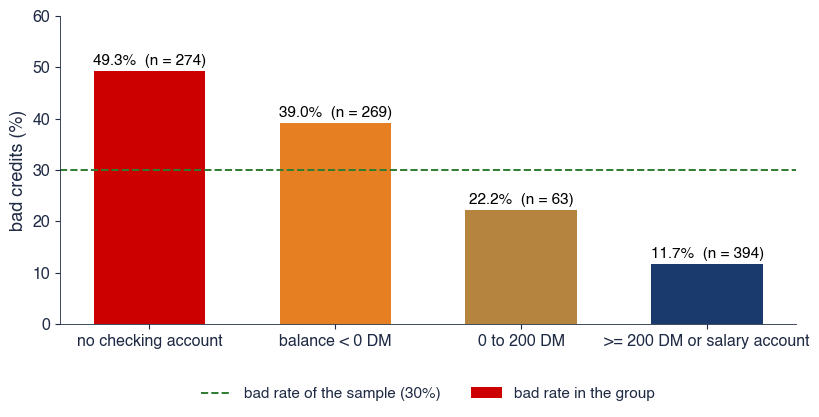

In [6]:
df = load_credit('sgc')
print(df.shape, df['default'].mean())
fig_default_by_status(df, save=False)

In [7]:
woe_table(df['status'], df['default'], 'status').round(3)

,n,bad,good,bad_rate,dist_good,dist_bad,woe,iv
bin,,,,,,,,
1,274,135,139,0.493,0.199,0.450,-0.818,0.206
2,269,105,164,0.390,0.234,0.350,-0.401,0.046
3,63,14,49,0.222,0.070,0.047,0.405,0.009
4,394,46,348,0.117,0.497,0.153,1.176,0.404


## 2. Weight of Evidence and Information Value

- $\mathrm{WoE}_i = \ln[(g_i/G)/(b_i/B)]$; $\mathrm{IV} = \sum_i (g_i/G - b_i/B)\,\mathrm{WoE}_i$.
- Rule of thumb (Siddiqi, 2006): below 0.02 useless, 0.02–0.1 weak, 0.1–0.3 medium, above 0.3 strong.

In [8]:
def fig_woe_duration(df=None, save=True):
    """WoE of the duration bins (bars) and their bad rate (line, right axis)."""
    df = load_credit('sgc') if df is None else df
    t = woe_table(df['duration'], df['default'], 'duration')
    labs = ['<= 12', '13-18', '19-24', '25-36', '> 36']
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    x = np.arange(len(t))
    ax.bar(x, t['woe'], color=[st.MainBlue if w > 0 else st.IDAred for w in t['woe']], width=0.6,
           label='WoE = ln(share of goods / share of bads)')
    ax.axhline(0, color=st.DarkText, lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{l}\n(n = {int(n)})' for l, n in zip(labs, t['n'])])
    ax.set_xlabel('duration of the credit (months)')
    ax.set_ylabel('weight of evidence')
    ax2 = ax.twinx()
    ax2.plot(x, 100 * t['bad_rate'], color=st.Amber, marker='o', lw=2, label='bad rate (%, right axis)')
    ax2.set_ylabel('bad rate (%)')
    ax2.set_ylim(0, 60)
    ax2.spines['right'].set_visible(True)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_woe_duration')
    return {'woe': t['woe'].round(4).tolist(), 'bad_rate': t['bad_rate'].round(4).tolist(), 'n': t['n'].tolist(),
            'iv': float(t['iv'].sum())}


def fig_iv(df=None, save=True):
    """Information value of the 20 variables (full sample), coloured by Siddiqi's strength classes."""
    df = load_credit('sgc') if df is None else df
    iv = iv_all(df, df['default'])
    col = {'strong': st.IDAred, 'medium': st.Orange, 'weak': st.Amber, 'useless': st.MainBlue}
    fig, ax = plt.subplots(figsize=(10, 5.4))
    y = np.arange(len(iv))[::-1]
    for cls in ['strong', 'medium', 'weak', 'useless']:
        m = np.array([iv_strength(v) == cls for v in iv.values])
        ax.barh(y[m], iv.values[m], color=col[cls], height=0.7, label=cls)
    ax.set_yticks(y)
    ax.set_yticklabels([v.replace('_', ' ') for v in iv.index], fontsize=10.5)
    for v in (0.02, 0.1, 0.3):
        ax.axvline(v, color=st.DarkText, ls=':', lw=1)
    ax.set_xlabel('information value (IV)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_iv')
    return {k: float(v) for k, v in iv.items()}

{'woe': [0.4674, 0.0025, 0.0256, -0.436, -0.9163],
 'bad_rate': [0.2117, 0.2995, 0.2946, 0.3986, 0.5172],
 'n': [359, 187, 224, 143, 87],
 'iv': 0.18244582833836792}

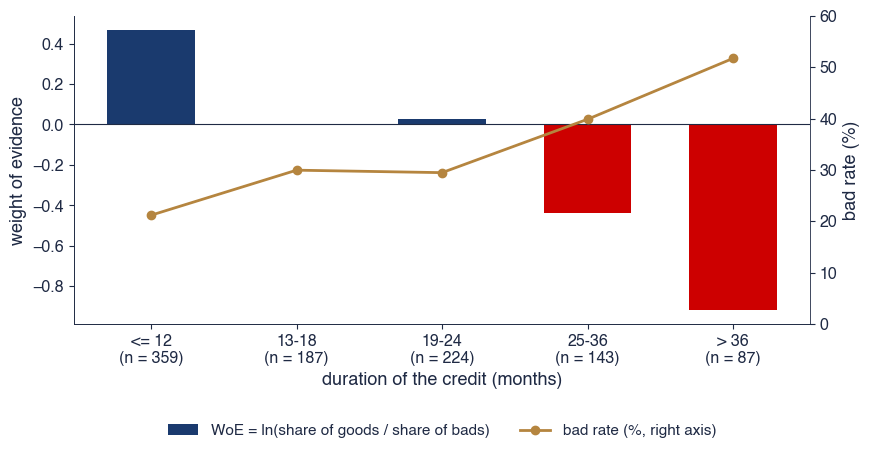

In [9]:
fig_woe_duration(df, save=False)

status                     0.666
credit_history             0.293
savings                    0.196
duration                   0.182
purpose                    0.169
property                   0.113
age                        0.089
employment_duration        0.086
housing                    0.085
amount                     0.082
other_installment_plans    0.058
personal_status_sex        0.045
foreign_worker             0.044
other_debtors              0.032
installment_rate           0.026
number_credits             0.013
job                        0.009
telephone                  0.006
present_residence          0.004
people_liable              0.000
dtype: float64

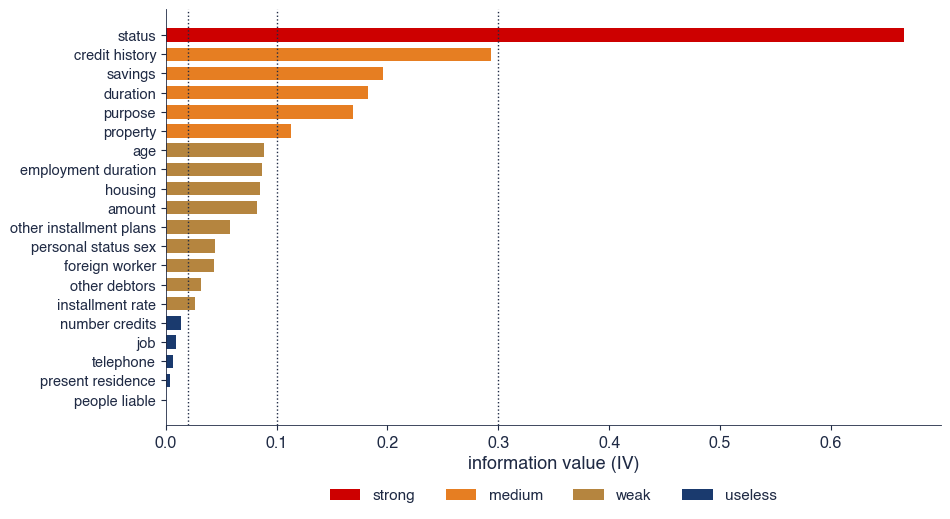

In [10]:
pd.Series(fig_iv(df, save=False)).round(3)

## 3. Logistic regression

- $\ln[p/(1-p)] = \beta_0 + x^\top\beta$, estimated by maximum likelihood (Newton–Raphson); $e^{\beta_j}$ is an odds ratio.

In [11]:
def logit_fit(X, y):
    """Logistic regression by maximum likelihood (Newton-Raphson): ln(p/(1-p)) = b0 + x'b.
    Returns the coefficients (constant first), standard errors and the log-likelihood."""
    X = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
    y = np.asarray(y, float)
    b = np.zeros(X.shape[1])
    for _ in range(100):
        p = 1 / (1 + np.exp(-X @ b))
        W = p * (1 - p)
        H = X.T @ (X * W[:, None])
        step = np.linalg.solve(H, X.T @ (y - p))
        b += step
        if np.max(np.abs(step)) < 1e-10:
            break
    p = 1 / (1 + np.exp(-X @ b))
    H = X.T @ (X * (p * (1 - p))[:, None])
    se = np.sqrt(np.diag(np.linalg.inv(H)))
    ll = float(np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)))
    return {'b': b, 'se': se, 'll': ll, 'n': len(y)}


def logit_predict(fit, X):
    X = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
    return 1 / (1 + np.exp(-X @ fit['b']))


def lda_fit(X, y):
    """Fisher's linear discriminant: w = S_W^{-1}(m_1 - m_0) maximises the between/within variance ratio of w'x;
    with Normal classes and a common covariance, ln odds(bad | x) = c + w'x (the prior enters only c)."""
    X = np.asarray(X, float)
    y = np.asarray(y)
    m0, m1 = X[y == 0].mean(0), X[y == 1].mean(0)
    n0, n1 = (y == 0).sum(), (y == 1).sum()
    S = ((X[y == 0] - m0).T @ (X[y == 0] - m0) + (X[y == 1] - m1).T @ (X[y == 1] - m1)) / (n0 + n1 - 2)
    w = np.linalg.solve(S, m1 - m0)
    pi1 = n1 / (n0 + n1)
    c = -0.5 * (m1 + m0) @ w + np.log(pi1 / (1 - pi1))
    return {'w': w, 'c': float(c), 'm0': m0, 'm1': m1, 'S': S, 'pi1': float(pi1)}


def lda_predict(fit, X):
    """Posterior probability of default from the LDA log-odds."""
    return 1 / (1 + np.exp(-(fit['c'] + np.asarray(X, float) @ fit['w'])))


def small_logit(df=None):
    """Interpretable logit on the full sample: duration (years), age (decades), amount (1000 DM) and the two riskiest
    checking-account groups; odds ratios exp(b) with 95% confidence intervals exp(b -+ 1.96 se)."""
    df = load_credit('sgc') if df is None else df
    X = pd.DataFrame({'duration_years': df['duration'] / 12, 'age_decades': df['age'] / 10,
                      'amount_1000': df['amount'] / 1000, 'no_account': (df['status'] == 1).astype(int),
                      'negative_balance': (df['status'] == 2).astype(int)})
    f = logit_fit(X, df['default'])
    names = ['const'] + list(X.columns)
    t = pd.DataFrame({'b': f['b'], 'se': f['se']}, index=names)
    t['z'] = t['b'] / t['se']
    t['p'] = 2 * stats.norm.sf(np.abs(t['z']))
    t['or'] = np.exp(t['b'])
    t['or_lo'] = np.exp(t['b'] - 1.96 * t['se'])
    t['or_hi'] = np.exp(t['b'] + 1.96 * t['se'])
    f0 = logit_fit(np.zeros((len(df), 0)), df['default'])
    return {'table': t, 'll': f['ll'], 'll0': f0['ll'], 'lr': 2 * (f['ll'] - f0['ll']), 'n': f['n'], 'fit': f, 'X': X}


def fig_logistic_curve(df=None, save=True):
    """Bad rate by duration (dots, size = number of credits) and the fitted logistic curve of duration alone."""
    df = load_credit('sgc') if df is None else df
    f = logit_fit(df[['duration']], df['default'])
    g = df.groupby('duration')['default'].agg(['size', 'mean'])
    g = g[g['size'] >= 5]
    xs = np.linspace(0, 75, 300)
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    ax.scatter(g.index, g['mean'], s=3 * g['size'], color=st.MainBlue, alpha=0.7,
               label='observed bad rate (durations with at least 5 credits)')
    ax.plot(xs, 1 / (1 + np.exp(-(f['b'][0] + f['b'][1] * xs))), color=st.IDAred, lw=2.2,
            label=f'logit: PD = 1 / (1 + exp(-({f["b"][0]:.2f} + {f["b"][1]:.3f} duration)))')
    ax.set_xlabel('duration (months)')
    ax.set_ylabel('probability of default')
    ax.set_ylim(0, 1)
    st.legend_outside_bottom(ax, ncol=1, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_logistic_curve')
    return {'b0': float(f['b'][0]), 'b1': float(f['b'][1]), 'se1': float(f['se'][1])}


def fig_odds_ratios(L=None, save=True):
    """Odds ratios exp(b) of the small logit with 95% confidence intervals (log scale)."""
    L = small_logit() if L is None else L
    t = L['table'].drop('const')
    labs = {'duration_years': 'duration (+1 year)', 'age_decades': 'age (+10 years)', 'amount_1000': 'amount (+1000 DM)',
            'no_account': 'no checking account', 'negative_balance': 'balance < 0 DM'}
    fig, ax = plt.subplots(figsize=(9.5, 3.8))
    y = np.arange(len(t))[::-1]
    ax.errorbar(t['or'], y, xerr=[t['or'] - t['or_lo'], t['or_hi'] - t['or']], fmt='o', color=st.IDAred,
                ecolor=st.MainBlue, capsize=4, lw=2, label='odds ratio exp(b) with 95% confidence interval')
    ax.axvline(1, color=st.DarkText, ls='--', lw=1)
    ax.set_xscale('log')
    ax.set_xticks([0.5, 1, 2, 4, 8])
    ax.set_xticklabels(['0.5', '1', '2', '4', '8'])
    ax.set_yticks(y)
    ax.set_yticklabels([labs[i] for i in t.index])
    ax.set_xlabel('odds ratio (log scale)')
    st.legend_outside_bottom(ax, ncol=1, y=-0.25)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_odds_ratios')

{'b0': -1.6663513810757862,
 'b1': 0.03753768625428554,
 'se1': 0.005702662155638769}

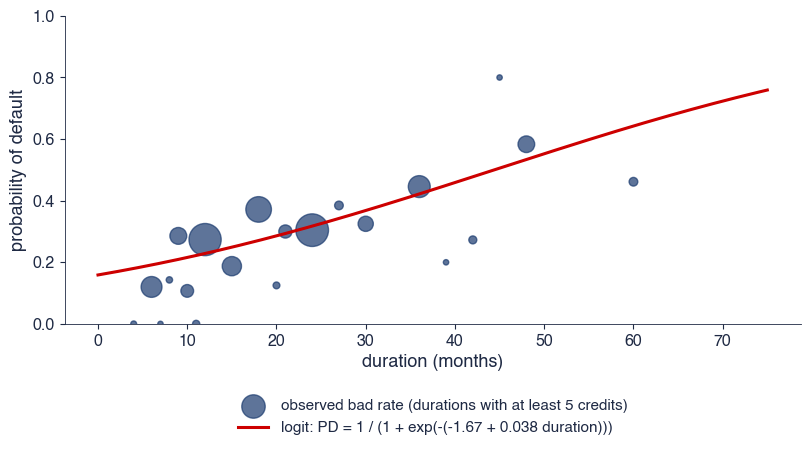

In [12]:
fig_logistic_curve(df, save=False)

In [13]:
L = small_logit(df)
print('LR statistic', round(L['lr'], 1))
L['table'].round(3)

LR statistic 169.6


,b,se,z,p,or,or_lo,or_hi
const,-2.101,0.311,-6.747,0.000,0.122,0.066,0.225
duration_years,0.385,0.092,4.165,0.000,1.470,1.226,1.762
age_decades,-0.159,0.069,-2.299,0.022,0.853,0.744,0.977
amount_1000,0.029,0.032,0.899,0.368,1.029,0.967,1.096
no_account,1.859,0.188,9.894,0.000,6.419,4.441,9.277
negative_balance,1.338,0.192,6.988,0.000,3.813,2.619,5.549


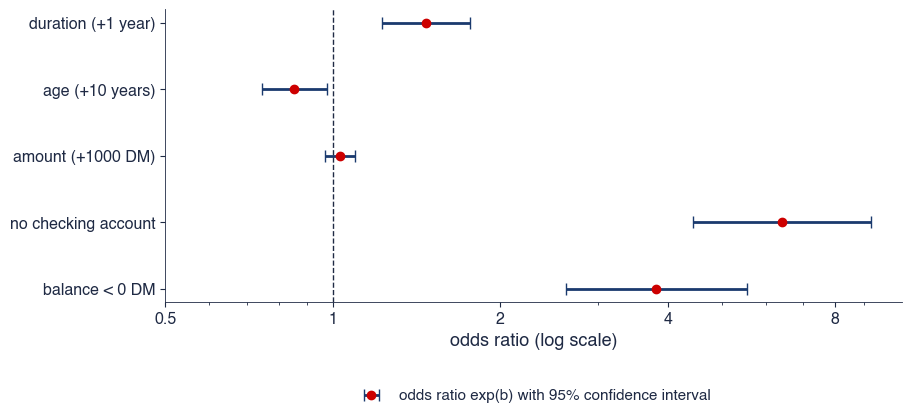

In [14]:
fig_odds_ratios(L, save=False)

## 4. Fisher's linear discriminant analysis

- $w = S_W^{-1}(m_1 - m_0)$; boundaries of LDA and logit for duration and age.

In [15]:
def fig_lda_2d(df=None, save=True):
    """Duration and age of goods and bads; the Fisher LDA and the logit boundaries at PD = 30% (sample rate)."""
    df = load_credit('sgc') if df is None else df
    X = df[['duration', 'age']].values.astype(float)
    y = df['default'].values
    ld, lg = lda_fit(X, y), logit_fit(X, y)
    rng = np.random.default_rng(SEED)
    J = X + rng.uniform(-0.4, 0.4, X.shape)
    fig, ax = plt.subplots(figsize=(9.5, 4.4))
    ax.scatter(J[y == 0, 0], J[y == 0, 1], s=9, color=COLORS['good'], alpha=0.45, label='good credit')
    ax.scatter(J[y == 1, 0], J[y == 1, 1], s=12, color=COLORS['bad'], alpha=0.65, marker='x', label='bad credit')
    xs = np.linspace(4, 72, 50)
    t = np.log(0.3 / 0.7)
    ax.plot(xs, (t - ld['c'] - ld['w'][0] * xs) / ld['w'][1], color=st.Forest, lw=2.4,
            label='Fisher LDA: PD = 30%')
    ax.plot(xs, (t - lg['b'][0] - lg['b'][1] * xs) / lg['b'][2], color=st.Orange, lw=2.4, ls='--',
            label='logit: PD = 30%')
    ax.set_xlim(2, 74)
    ax.set_ylim(17, 77)
    ax.set_xlabel('duration (months)')
    ax.set_ylabel('age (years)')
    st.legend_outside_bottom(ax, ncol=4, y=-0.17)
    leg = ax.get_legend()
    for h in leg.legend_handles:
        if hasattr(h, 'set_alpha'):
            h.set_alpha(1)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_lda_2d')
    return {'m0': ld['m0'].tolist(), 'm1': ld['m1'].tolist(), 'S': ld['S'].tolist(), 'w': ld['w'].tolist(),
            'c': ld['c'], 'logit_b': lg['b'].tolist(), 'logit_se': lg['se'].tolist(), 'n0': int((y == 0).sum()),
            'n1': int((y == 1).sum())}

{'m0': [19.207142857142856, 36.22],
 'm1': [24.86, 33.96],
 'S': [[138.83675780131713, -2.457494989979969],
  [-2.457494989979969, 127.93751503006004]],
 'w': [0.04041691675708997, -0.01688852272182512],
 'c': -1.1452086203683274,
 'logit_b': [-1.0238595956839174, 0.03747397026988919, -0.018322959693934382],
 'logit_se': [0.27081215964288535, 0.005734753819989332, 0.006658233759976329],
 'n0': 700,
 'n1': 300}

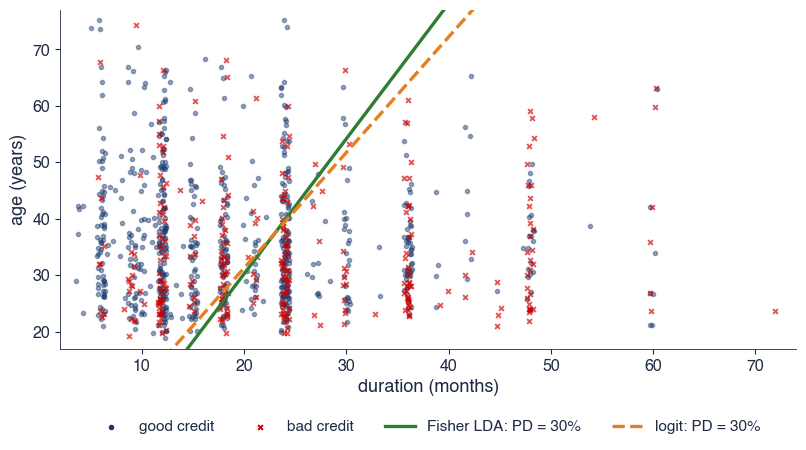

In [16]:
fig_lda_2d(df, save=False)

## 5. The WoE scorecard

- Stratified 70/30 split; WoE and IV on the training sample; variables with IV ≥ 0.10; logit and LDA on the WoE values.
- Scaling: 20 points to double the odds, 600 points at good:bad odds of 50:1; prior correction to 5%.

In [17]:
def scaling(pdo=PDO, base=BASE_SCORE, odds=BASE_ODDS):
    """Score = offset + factor ln(good:bad odds): factor = PDO / ln 2, offset = base - factor ln(odds)."""
    factor = pdo / np.log(2)
    return {'factor': float(factor), 'offset': float(base - factor * np.log(odds))}


def points_table(fit, tables, variables):
    """Points of every attribute: -(b_j WoE_ij + b_0/k) factor + offset/k (k variables, logit for the bads);
    the score of an applicant is the sum of its points."""
    sc = scaling()
    k = len(variables)
    rows = []
    for j, v in enumerate(variables):
        for bn, r in tables[v].iterrows():
            pts = -(fit['b'][j + 1] * r['woe'] + fit['b'][0] / k) * sc['factor'] + sc['offset'] / k
            rows.append({'variable': v, 'bin': bn, 'n': int(r['n']), 'bad_rate': r['bad_rate'], 'woe': r['woe'],
                         'points': pts})
    return pd.DataFrame(rows)


def score_from_pd(p):
    """Score of a PD: offset + factor ln((1 - p)/p)."""
    sc = scaling()
    return sc['offset'] + sc['factor'] * np.log((1 - np.asarray(p)) / np.asarray(p))


def prior_shift(sample_bad, pop_bad):
    """Correction of the log-odds for oversampled bads: ln odds_pop = ln odds_sample + ln(odds of pop / sample)."""
    return float(np.log(pop_bad / (1 - pop_bad)) - np.log(sample_bad / (1 - sample_bad)))


def sgc_scorecard(df=None):
    """WoE tables and IV on the training sample, variables with IV >= IV_MIN, WoE logit and LDA; test predictions."""
    df = load_credit('sgc') if df is None else df
    y = df['default'].values
    tr, te = stratified_split(y)
    tables = {v: woe_table(df[v].iloc[tr], y[tr], v) for v in SGC_VARS}
    iv = pd.Series({v: tables[v]['iv'].sum() for v in SGC_VARS}).sort_values(ascending=False)
    sel = [v for v in iv.index if iv[v] >= IV_MIN]
    Xtr, Xte = woe_transform(df.iloc[tr], tables, sel), woe_transform(df.iloc[te], tables, sel)
    lg = logit_fit(Xtr, y[tr])
    ld = lda_fit(Xtr, y[tr])
    out = {'tr': tr, 'te': te, 'y': y, 'tables': tables, 'iv': iv, 'sel': sel, 'logit': lg, 'lda': ld,
           'p_tr': logit_predict(lg, Xtr), 'p_te': logit_predict(lg, Xte), 'q_te': lda_predict(ld, Xte),
           'Xtr': Xtr, 'Xte': Xte}
    out['single_te'] = -woe_transform(df.iloc[te], tables, ['status'])['status'].values   # status alone (-WoE)
    return out


def fig_score_dist(S, save=True):
    """Scorecard points of the test sample, goods and bads; the cost-based cut-off."""
    y = S['y'][S['te']]
    sc = score_from_pd(S['p_te'])
    cut = float(score_from_pd(COST_FP / (COST_FP + COST_FN)))
    bins = np.arange(np.floor(sc.min() / 10) * 10, np.ceil(sc.max() / 10) * 10 + 10, 10)
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    ax.hist(sc[y == 0], bins=bins, color=COLORS['good'], alpha=0.6, label='good credits (test sample)')
    ax.hist(sc[y == 1], bins=bins, color=COLORS['bad'], alpha=0.6, label='bad credits (test sample)')
    ax.axvline(cut, color=st.Forest, lw=2, ls='--', label=f'cut-off at PD = 1/6: {cut:.0f} points')
    ax.set_xlabel('score (points; 600 = good:bad odds of 50:1, +20 points = double odds)')
    ax.set_ylabel('number of credits')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_score_dist')
    return {'cut': cut, 'mean_good': float(sc[y == 0].mean()), 'mean_bad': float(sc[y == 1].mean()),
            'min': float(sc.min()), 'max': float(sc.max())}

In [18]:
S = sgc_scorecard(df)
print(S['sel'])
pd.DataFrame({'b': S['logit']['b'], 'se': S['logit']['se']}, index=['const'] + S['sel']).round(3)

['status', 'credit_history', 'purpose', 'savings', 'duration', 'employment_duration']


,b,se
const,-0.850,0.095
status,-0.829,0.127
credit_history,-0.675,0.206
purpose,-0.937,0.217
savings,-0.726,0.246
duration,-1.082,0.239
employment_duration,-0.873,0.265


In [19]:
print(scaling(), prior_shift(0.3, POP_BAD))
points_table(S['logit'], S['tables'], S['sel']).round(2)

{'factor': 28.85390081777927, 'offset': 487.1228762045055} -2.097141118779237


,variable,bin,n,bad_rate,woe,points
0,status,1,190,0.49,-0.83,65.51
1,status,2,189,0.38,-0.34,77.16
2,status,3,39,0.21,0.51,97.41
3,status,4,282,0.13,1.04,110.23
4,credit_history,0,26,0.54,-1.00,65.76
5,credit_history,1,34,0.50,-0.85,68.77
6,credit_history,2,376,0.32,-0.10,83.29
7,credit_history,3,56,0.38,-0.34,78.72
8,credit_history,4,208,0.18,0.68,98.59
9,purpose,0,166,0.35,-0.22,79.21


{'cut': 533.5614381022527,
 'mean_good': 528.7731641790729,
 'mean_bad': 491.9885655807712,
 'min': 421.5723290776264,
 'max': 607.2089409539237}

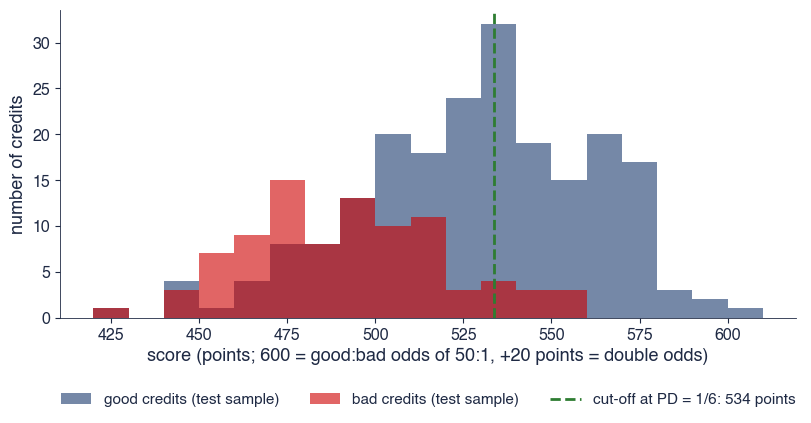

In [20]:
fig_score_dist(S, save=False)

## 6. Validation

- Confusion matrix at the cut-offs 0.5 and 1/6 (costs 5:1); ROC, AUC with DeLong standard errors, Gini, CAP and the accuracy ratio, KS, Brier score, Hosmer–Lemeshow.
- Repeated stratified 5-fold cross-validation, with the WoE bins and the selection redone inside every fold.

In [21]:
def auc(score, y):
    """AUC = P(score of a random bad > score of a random good) (ties count 1/2), via the Mann-Whitney ranks."""
    score, y = np.asarray(score, float), np.asarray(y)
    r = stats.rankdata(score)
    n1, n0 = (y == 1).sum(), (y == 0).sum()
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def delong(score, y, score2=None):
    """DeLong et al. (1988): standard error of the AUC; with a second score on the same cases, the test of
    equal AUCs (z statistic and two-sided p-value)."""
    def comps(s):
        s = np.asarray(s, float)
        pos, neg = s[np.asarray(y) == 1], s[np.asarray(y) == 0]
        v10 = np.array([np.mean((p > neg) + 0.5 * (p == neg)) for p in pos])
        v01 = np.array([np.mean((pos > q) + 0.5 * (pos == q)) for q in neg])
        return v10, v01
    a10, a01 = comps(score)
    A = a10.mean()
    if score2 is None:
        var = np.var(a10, ddof=1) / len(a10) + np.var(a01, ddof=1) / len(a01)
        return {'auc': float(A), 'se': float(np.sqrt(var)), 'lo': float(A - 1.96 * np.sqrt(var)),
                'hi': float(A + 1.96 * np.sqrt(var))}
    b10, b01 = comps(score2)
    S10 = np.cov(np.vstack([a10, b10]))
    S01 = np.cov(np.vstack([a01, b01]))
    var = (S10[0, 0] + S10[1, 1] - 2 * S10[0, 1]) / len(a10) + (S01[0, 0] + S01[1, 1] - 2 * S01[0, 1]) / len(a01)
    z = (A - b10.mean()) / np.sqrt(var)
    return {'auc1': float(A), 'auc2': float(b10.mean()), 'z': float(z), 'p': float(2 * stats.norm.sf(abs(z)))}


def roc_points(score, y):
    """ROC curve: (FPR, TPR) when every score value is used as the cut-off (a higher score = riskier)."""
    score, y = np.asarray(score, float), np.asarray(y)
    thr = np.r_[np.inf, np.unique(score)[::-1]]
    tpr = np.array([np.mean(score[y == 1] >= t) for t in thr])
    fpr = np.array([np.mean(score[y == 0] >= t) for t in thr])
    return fpr, tpr, thr


def cap_points(score, y):
    """CAP (cumulative accuracy profile): share of all bads among the riskiest x% of the applicants."""
    score, y = np.asarray(score, float), np.asarray(y)
    order = np.argsort(-score, kind='mergesort')
    x = np.r_[0, np.arange(1, len(y) + 1) / len(y)]
    hit = np.r_[0, np.cumsum(y[order]) / y.sum()]
    return x, hit


def accuracy_ratio(score, y):
    """AR = (area between the model CAP and the diagonal) / (area between the perfect CAP and the diagonal);
    for a continuous score AR = Gini = 2 AUC - 1."""
    x, hit = cap_points(score, y)
    a_model = np.trapezoid(hit, x) - 0.5
    pbad = np.mean(y)
    a_perf = (1 - pbad / 2) - 0.5
    return float(a_model / a_perf)


def ks_stat(score, y):
    """Kolmogorov-Smirnov: the largest distance between the score distributions of the bads and the goods."""
    score, y = np.asarray(score, float), np.asarray(y)
    s = np.sort(np.unique(score))
    F1 = np.searchsorted(np.sort(score[y == 1]), s, side='right') / (y == 1).sum()
    F0 = np.searchsorted(np.sort(score[y == 0]), s, side='right') / (y == 0).sum()
    i = int(np.argmax(np.abs(F0 - F1)))
    return {'ks': float(np.abs(F0 - F1)[i]), 'at': float(s[i]), 's': s, 'F1': F1, 'F0': F0}


def brier(p, y):
    """Brier score: the mean squared difference between the predicted PD and the outcome (0 or 1)."""
    return float(np.mean((np.asarray(p) - np.asarray(y)) ** 2))


def calibration_table(p, y, k=10):
    """Mean predicted PD and observed default rate in k groups of equal size (sorted by PD); Hosmer-Lemeshow."""
    d = pd.DataFrame({'p': np.asarray(p), 'y': np.asarray(y)}).sort_values('p').reset_index(drop=True)
    d['g'] = np.arange(len(d)) * k // len(d)
    t = d.groupby('g').agg(n=('y', 'size'), pd_mean=('p', 'mean'), rate=('y', 'mean'), bad=('y', 'sum'))
    exp = t['n'] * t['pd_mean']
    hl = float((((t['bad'] - exp) ** 2) / (exp * (1 - t['pd_mean']))).sum())
    return t, hl, float(stats.chi2.sf(hl, k - 2))


def confusion(p, y, cut):
    """Reject (predict bad) if PD > cut. TP: bad rejected; FN: bad accepted; FP: good rejected; TN: good accepted."""
    p, y = np.asarray(p), np.asarray(y)
    pred = (p > cut).astype(int)
    TP = int(np.sum((pred == 1) & (y == 1)))
    FN = int(np.sum((pred == 0) & (y == 1)))
    FP = int(np.sum((pred == 1) & (y == 0)))
    TN = int(np.sum((pred == 0) & (y == 0)))
    n = len(y)
    return {'cut': float(cut), 'TP': TP, 'FN': FN, 'FP': FP, 'TN': TN, 'acc': (TP + TN) / n,
            'tpr': TP / (TP + FN), 'tnr': TN / (TN + FP), 'fpr': FP / (TN + FP), 'precision': TP / max(TP + FP, 1),
            'cost': (COST_FN * FN + COST_FP * FP) / n, 'reject': (TP + FP) / n}


def validation(S):
    """All test-sample measures of the WoE logit scorecard and of the LDA."""
    y = S['y'][S['te']]
    p, q = S['p_te'], S['q_te']
    out = {'n_test': int(len(y)), 'bad_test': int(y.sum()), 'n_train': int(len(S['tr'])),
           'auc_train': auc(S['p_tr'], S['y'][S['tr']]), 'auc': auc(p, y), 'auc_lda': auc(q, y),
           'auc_single': auc(S['single_te'], y), 'delong': delong(p, y), 'delong_lda': delong(p, y, q),
           'delong_single': delong(p, y, S['single_te']), 'gini': 2 * auc(p, y) - 1, 'ar': accuracy_ratio(p, y),
           'ks': ks_stat(p, y)['ks'], 'ks_score': float(score_from_pd(ks_stat(p, y)['at'])),
           'brier': brier(p, y), 'brier_ref': brier(np.full(len(y), np.mean(S['y'][S['tr']])), y),
           'cm50': confusion(p, y, 0.5), 'cm_cost': confusion(p, y, COST_FP / (COST_FP + COST_FN)),
           'corr_logit_lda': float(np.corrcoef(np.log(p / (1 - p)), np.log(q / (1 - q)))[0, 1])}
    t, hl, php = calibration_table(p, y, 10)
    out['hl'], out['hl_p'] = hl, php
    out['all_good'] = float(np.mean(y == 0))
    return out


def cv_auc(df=None, n_repeat=N_REPEAT, n_fold=N_FOLD, seed=SEED):
    """Repeated stratified k-fold cross-validation; WoE tables and variable selection are redone inside every
    training fold (otherwise the test folds leak into the bins). Train and test AUC of four models."""
    df = load_credit('sgc') if df is None else df
    y = df['default'].values
    rng = np.random.default_rng(seed)
    res = {m: {'train': [], 'test': []} for m in ['WoE logit', 'LDA', 'small logit', 'status only']}
    Xs = small_logit(df)['X'].values
    for r in range(n_repeat):
        folds = np.empty(len(y), int)
        for c in (0, 1):
            idx = np.flatnonzero(y == c)
            rng.shuffle(idx)
            folds[idx] = np.arange(len(idx)) % n_fold
        for k in range(n_fold):
            tr, te = np.flatnonzero(folds != k), np.flatnonzero(folds == k)
            tabs = {v: woe_table(df[v].iloc[tr], y[tr], v) for v in SGC_VARS}
            sel = [v for v in SGC_VARS if tabs[v]['iv'].sum() >= IV_MIN]
            Xtr, Xte = woe_transform(df.iloc[tr], tabs, sel), woe_transform(df.iloc[te], tabs, sel)
            lg, ld, sm = logit_fit(Xtr, y[tr]), lda_fit(Xtr, y[tr]), logit_fit(Xs[tr], y[tr])
            pairs = {'WoE logit': (logit_predict(lg, Xtr), logit_predict(lg, Xte)),
                     'LDA': (lda_predict(ld, Xtr), lda_predict(ld, Xte)),
                     'small logit': (logit_predict(sm, Xs[tr]), logit_predict(sm, Xs[te])),
                     'status only': (-Xtr.get('status', pd.Series(0, index=Xtr.index)).values,
                                     -Xte.get('status', pd.Series(0, index=Xte.index)).values)}
            for m, (a, b) in pairs.items():
                res[m]['train'].append(auc(a, y[tr]))
                res[m]['test'].append(auc(b, y[te]))
    return res


def fig_roc(S, save=True):
    """ROC curves on the test sample: WoE logit, Fisher LDA, the checking-account status alone."""
    y = S['y'][S['te']]
    fig, ax = plt.subplots(figsize=(6.4, 5.0))
    for lab, s, c, ls in [('WoE logit', S['p_te'], COLORS['logit'], '-'), ('Fisher LDA', S['q_te'], COLORS['lda'], '--'),
                          ('checking account only', S['single_te'], COLORS['single'], '-')]:
        f, t, _ = roc_points(s, y)
        ax.plot(f, t, color=c, lw=2.2, ls=ls, label=f'{lab} (AUC = {auc(s, y):.3f})')
    ax.plot([0, 1], [0, 1], color=COLORS['random'], ls=':', lw=1.5, label='random score (AUC = 0.5)')
    ax.set_xlabel('false positive rate: goods rejected (1 - specificity)')
    ax.set_ylabel('true positive rate: bads rejected')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_roc')


def fig_cap(S, save=True):
    """CAP curves on the test sample: model, random and perfect; AR in the legend."""
    y = S['y'][S['te']]
    p = S['p_te']
    x, h = cap_points(p, y)
    pb = y.mean()
    fig, ax = plt.subplots(figsize=(6.4, 5.0))
    ax.plot(x, h, color=COLORS['logit'], lw=2.2, label=f'WoE logit (AR = {accuracy_ratio(p, y):.3f})')
    ax.plot([0, pb, 1], [0, 1, 1], color=COLORS['perfect'], lw=2, ls='--', label='perfect model (AR = 1)')
    ax.plot([0, 1], [0, 1], color=COLORS['random'], ls=':', lw=1.5, label='random score (AR = 0)')
    ax.fill_between(x, x, h, color=COLORS['logit'], alpha=0.12)
    ax.set_xlabel('share of applicants, riskiest first')
    ax.set_ylabel('share of all bads captured')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    st.legend_outside_bottom(ax, ncol=1, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_cap')


def fig_ks(S, save=True):
    """Empirical distribution functions of the score for goods and bads; the KS distance."""
    y = S['y'][S['te']]
    sc = score_from_pd(S['p_te'])
    k = ks_stat(-sc, y)                     # risk order: a low score is risky
    s = np.sort(np.unique(sc))
    F1 = np.searchsorted(np.sort(sc[y == 1]), s, side='right') / (y == 1).sum()
    F0 = np.searchsorted(np.sort(sc[y == 0]), s, side='right') / (y == 0).sum()
    i = int(np.argmax(F1 - F0))
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    ax.step(s, F1, where='post', color=COLORS['bad'], lw=2, label='bads: share with score <= s')
    ax.step(s, F0, where='post', color=COLORS['good'], lw=2, label='goods: share with score <= s')
    ax.vlines(s[i], F0[i], F1[i], color=st.Forest, lw=3, label=f'KS = {F1[i] - F0[i]:.3f} at {s[i]:.0f} points')
    ax.set_xlabel('score s (points)')
    ax.set_ylabel('cumulative share')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_ks')
    return {'ks': float(F1[i] - F0[i]), 'at': float(s[i]), 'ks_check': k['ks']}


def fig_cost_cutoff(S, save=True):
    """Test sample: expected cost per applicant (5 for an accepted bad, 1 for a rejected good) and the share of
    rejected applicants as functions of the PD cut-off."""
    y = S['y'][S['te']]
    p = S['p_te']
    cuts = np.linspace(0.02, 0.9, 89)
    cost = [confusion(p, y, c)['cost'] for c in cuts]
    rej = [confusion(p, y, c)['reject'] for c in cuts]
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    ax.plot(cuts, cost, color=st.IDAred, lw=2.2, label='expected cost per applicant')
    ax.axhline(COST_FN * y.mean(), color=st.Amber, ls='--', lw=1.5, label='accept everybody')
    ax.axhline(COST_FP * (1 - y.mean()), color=st.Purple, ls='--', lw=1.5, label='reject everybody')
    ax.axvline(COST_FP / (COST_FP + COST_FN), color=st.Forest, ls=':', lw=2, label='Bayes cut-off PD = 1/6')
    ax.set_xlabel('PD cut-off (reject if PD > cut-off)')
    ax.set_ylabel('cost per applicant')
    ax2 = ax.twinx()
    ax2.plot(cuts, 100 * np.array(rej), color=st.MainBlue, lw=1.8, label='rejected applicants (%, right axis)')
    ax2.set_ylabel('rejected (%)')
    ax2.spines['right'].set_visible(True)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_cost_cutoff')
    i = int(np.argmin(cost))
    return {'best_cut': float(cuts[i]), 'best_cost': float(cost[i]), 'cost_accept_all': float(COST_FN * y.mean()),
            'cost_reject_all': float(COST_FP * (1 - y.mean()))}


def fig_cv_auc(res, save=True):
    """Repeated cross-validation: train and test AUC of four models (one dot per fold)."""
    models = list(res)
    col = [COLORS['logit'], COLORS['lda'], COLORS['small'], COLORS['single']]
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    rng = np.random.default_rng(SEED)
    for i, (m, c) in enumerate(zip(models, col)):
        for j, (part, mk) in enumerate([('train', 'o'), ('test', 'x')]):
            v = np.array(res[m][part])
            xpos = i + (j - 0.5) * 0.36 + rng.uniform(-0.07, 0.07, len(v))
            ax.scatter(xpos, v, s=12, color=c, marker=mk, alpha=0.6,
                       label=('training folds' if part == 'train' else 'test folds') if i == 0 else None)
            ax.plot([i + (j - 0.5) * 0.36 - 0.14, i + (j - 0.5) * 0.36 + 0.14], [v.mean()] * 2, color='black', lw=2)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models)
    ax.set_ylabel('AUC')
    st.legend_outside_bottom(ax, ncol=2, y=-0.14)
    leg = ax.get_legend()
    for h in leg.legend_handles:
        h.set_color(st.DarkText)
        h.set_alpha(1)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_cv_auc')
    return {m: {p: {'mean': float(np.mean(v)), 'sd': float(np.std(v, ddof=1))} for p, v in d.items()}
            for m, d in res.items()}

In [22]:
Vd = validation(S)
print(Vd['cm50'])
print(Vd['cm_cost'])
{k: v for k, v in Vd.items() if not isinstance(v, dict)}

{'cut': 0.5, 'TP': 43, 'FN': 47, 'FP': 25, 'TN': 185, 'acc': 0.76, 'tpr': 0.4777777777777778, 'tnr': 0.8809523809523809, 'fpr': 0.11904761904761904, 'precision': 0.6323529411764706, 'cost': 0.8666666666666667, 'reject': 0.22666666666666666}
{'cut': 0.16666666666666666, 'TP': 82, 'FN': 8, 'FP': 112, 'TN': 98, 'acc': 0.6, 'tpr': 0.9111111111111111, 'tnr': 0.4666666666666667, 'fpr': 0.5333333333333333, 'precision': 0.422680412371134, 'cost': 0.5066666666666667, 'reject': 0.6466666666666666}


{'n_test': 300,
 'bad_test': 90,
 'n_train': 700,
 'auc_train': 0.789159378036929,
 'auc': 0.8013227513227513,
 'auc_lda': 0.8008994708994709,
 'auc_single': 0.728042328042328,
 'gini': 0.6026455026455027,
 'ar': 0.6020105820105821,
 'ks': 0.5111111111111111,
 'ks_score': 516.1431410014699,
 'brier': 0.16217283209875974,
 'brier_ref': 0.21,
 'corr_logit_lda': 0.9987166078671436,
 'hl': 6.519940522194601,
 'hl_p': 0.5891966898215442,
 'all_good': 0.7}

{'ks': 0.5111111111111111,
 'at': 515.7308392745895,
 'ks_check': 0.5111111111111111}

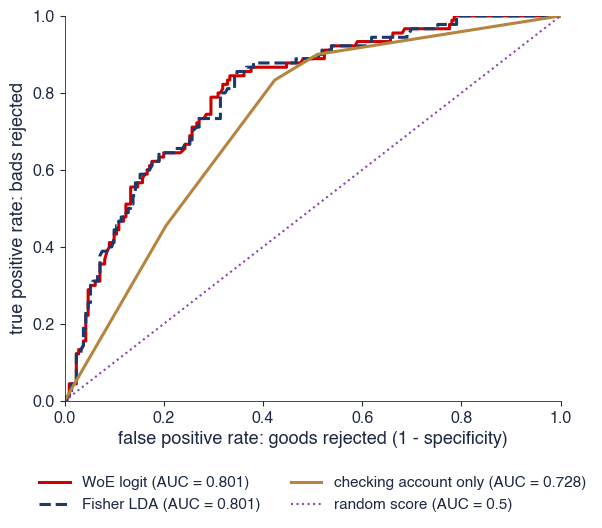

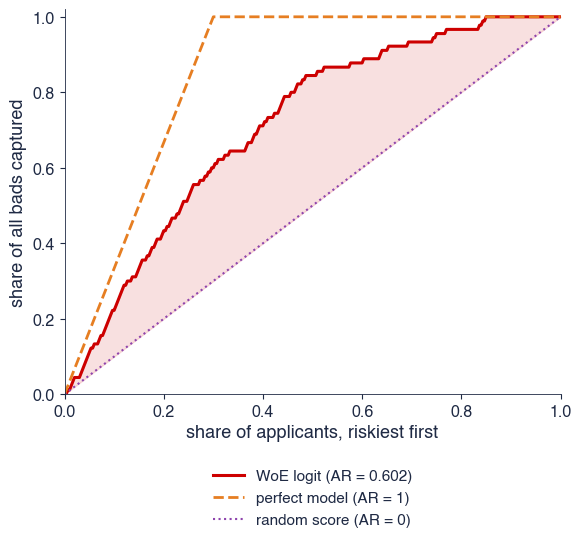

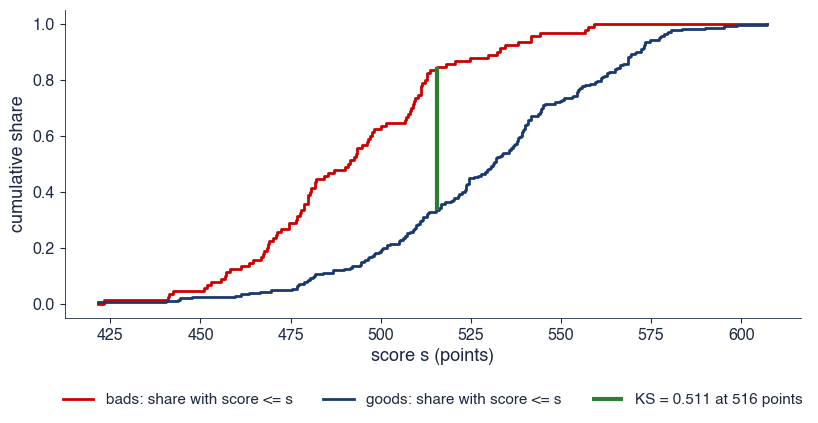

In [23]:
fig_roc(S, save=False)
fig_cap(S, save=False)
fig_ks(S, save=False)

{'best_cut': 0.27,
 'best_cost': 0.4666666666666667,
 'cost_accept_all': 1.5,
 'cost_reject_all': 0.7}

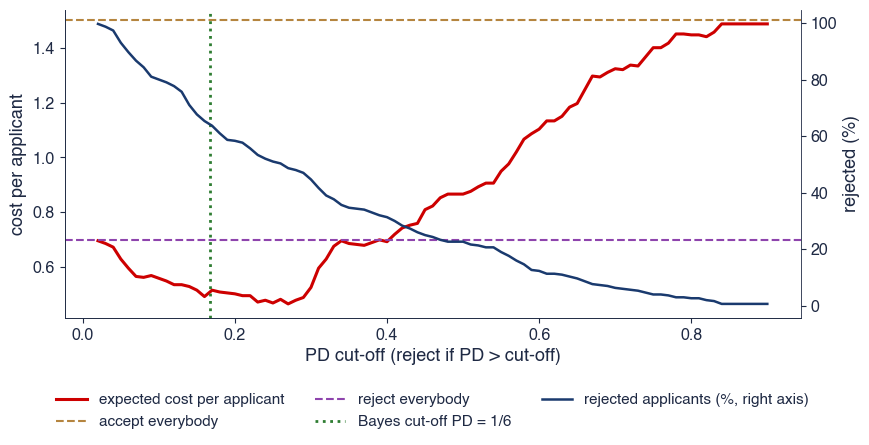

In [24]:
fig_cost_cutoff(S, save=False)

{'WoE logit': {'train': {'mean': 0.8035094494047617,
   'sd': 0.009890017225996832},
  'test': {'mean': 0.7644446428571428, 'sd': 0.031849933746627465}},
 'LDA': {'train': {'mean': 0.803914955357143, 'sd': 0.00992703081192422},
  'test': {'mean': 0.7654303571428571, 'sd': 0.031314041841804106}},
 'small logit': {'train': {'mean': 0.7494982142857145,
   'sd': 0.007587405344183562},
  'test': {'mean': 0.7442166666666666, 'sd': 0.030580948295219276}},
 'status only': {'train': {'mean': 0.7077647693452381,
   'sd': 0.007128196145934321},
  'test': {'mean': 0.7077005952380954, 'sd': 0.02861814719834353}}}

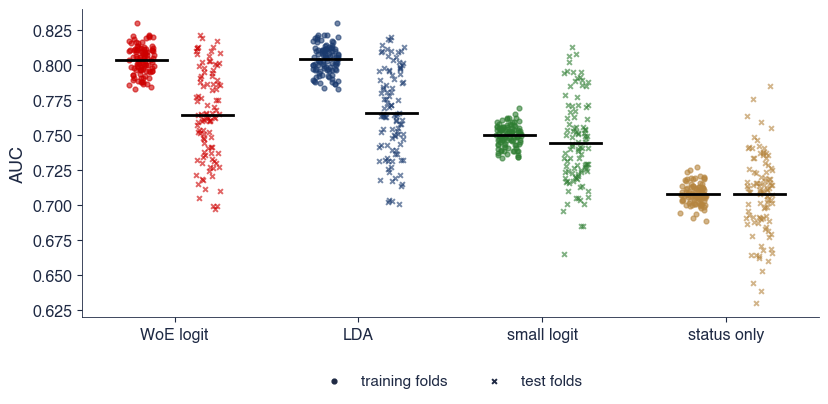

In [25]:
res = cv_auc(df)
fig_cv_auc(res, save=False)

## 7. Calibration on the Taiwan data

- A logit on 13 standardised inputs; ten groups of 900 test clients.

In [26]:
def taiwan_model(df=None):
    """Logit on the Taiwan data (70/30 stratified split); sex, education and marital status are not inputs."""
    df = load_credit('taiwan') if df is None else df
    X = taiwan_features(df)
    y = df['default'].values
    tr, te = stratified_split(y)
    mu, sd = X.iloc[tr].mean(), X.iloc[tr].std()
    Z = (X - mu) / sd
    f = logit_fit(Z.iloc[tr], y[tr])
    return {'df': df, 'X': X, 'Z': Z, 'y': y, 'tr': tr, 'te': te, 'fit': f, 'p': logit_predict(f, Z)}


def fig_calibration(T, save=True):
    """Calibration of the Taiwan logit on the test sample: mean PD against the observed rate in ten groups."""
    y, p = T['y'][T['te']], T['p'][T['te']]
    t, hl, php = calibration_table(p, y, 10)
    se = np.sqrt(t['rate'] * (1 - t['rate']) / t['n'])
    fig, ax = plt.subplots(figsize=(6.4, 5.0))
    ax.plot([0, 1], [0, 1], color=COLORS['random'], ls=':', lw=1.5, label='perfect calibration')
    ax.errorbar(t['pd_mean'], t['rate'], yerr=1.96 * se, fmt='o-', color=st.IDAred, ecolor=st.MainBlue, capsize=3,
                lw=2, label='ten groups of 900 test clients (95% interval)')
    ax.set_xlabel('mean predicted PD in the group')
    ax.set_ylabel('observed default rate in the group')
    ax.set_xlim(0, 0.8)
    ax.set_ylim(0, 0.8)
    st.legend_outside_bottom(ax, ncol=1, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_calibration')
    return {'hl': hl, 'hl_p': php, 'brier': brier(p, y), 'brier_ref': brier(np.full(len(y), T['y'][T['tr']].mean()), y),
            'auc': auc(p, y), 'auc_train': auc(T['p'][T['tr']], T['y'][T['tr']]), 'n_test': int(len(y)),
            'rate': float(y.mean()), 'groups': t.round(4).to_dict('index')}

{'hl': 40.66042560182408,
 'hl_p': 2.4125604485112416e-06,
 'brier': 0.13626072968914568,
 'brier_ref': 0.17228295162509452,
 'auc': 0.7771611214654847,
 'auc_train': 0.7740167482844148,
 'n_test': 9000,
 'rate': 0.2212222222222222}

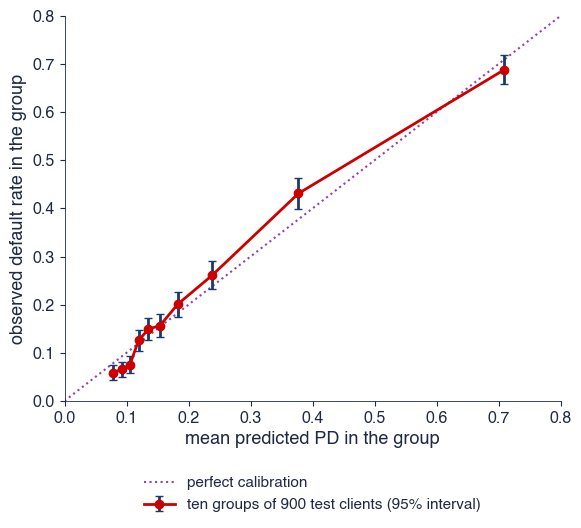

In [27]:
T = taiwan_model()
cal = fig_calibration(T, save=False)
{k: v for k, v in cal.items() if k != 'groups'}

## 8. Basel IRB capital

- $K = \mathrm{LGD}[\Phi((\Phi^{-1}(\mathrm{PD}) + \sqrt{R}\Phi^{-1}(0.999))/\sqrt{1-R}) - \mathrm{PD}]$, RWA $= 12.5\,K\,$EAD (Basel II, paragraphs 328–330).

In [28]:
def irb_capital(pd_, lgd=0.45, kind='other retail'):
    """Basel II IRB capital requirement K per unit of EAD (BCBS, 2006, paragraphs 328-330), retail exposures:
    K = LGD [N((G(PD) + sqrt(R) G(0.999)) / sqrt(1 - R)) - PD]; RWA = 12.5 K EAD."""
    pd_ = np.asarray(pd_, float)
    if kind == 'mortgage':
        R = 0.15 + 0 * pd_
    elif kind == 'revolving':
        R = 0.04 + 0 * pd_
    else:
        w = (1 - np.exp(-35 * pd_)) / (1 - np.exp(-35))
        R = 0.03 * w + 0.16 * (1 - w)
    K = lgd * (stats.norm.cdf((stats.norm.ppf(pd_) + np.sqrt(R) * stats.norm.ppf(0.999)) / np.sqrt(1 - R)) - pd_)
    return K, R


def fig_irb(save=True):
    """Expected loss PD x LGD and IRB capital K as functions of PD, LGD = 45%."""
    pds = np.linspace(0.0005, 0.25, 400)
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    ax.plot(100 * pds, 100 * 0.45 * pds, color=st.Amber, lw=2, label='expected loss EL = PD x LGD')
    for kind, c, ls in [('other retail', st.IDAred, '-'), ('mortgage', st.MainBlue, '--'), ('revolving', st.Forest, '-.')]:
        K, _ = irb_capital(pds, 0.45, kind)
        ax.plot(100 * pds, 100 * K, color=c, lw=2.2, ls=ls, label=f'capital K, {kind}')
    ax.set_xlabel('PD (%)')
    ax.set_ylabel('% of EAD')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_irb')


def conditional_pd(pd_, y, rho=0.2):
    """One-factor Gaussian model (Vasicek): borrower i defaults if sqrt(rho) Y + sqrt(1 - rho) e_i < N^-1(PD); given the
    state of the economy Y = y, PD(y) = N((N^-1(PD) - sqrt(rho) y) / sqrt(1 - rho)) (as in the SFE Quantlet SFEdefaproba)."""
    return stats.norm.cdf((stats.norm.ppf(pd_) - np.sqrt(rho) * y) / np.sqrt(1 - rho))


def fig_conditional_pd(rho=0.2, save=True):
    """Conditional PD against the unconditional PD for a bad (y = -3), a typical (y = 0) and a good (y = 3) state of
    the economy, rho = 0.2 (SFEdefaproba)."""
    x = np.linspace(0.001, 0.999, 400)
    fig, ax = plt.subplots(figsize=(9.5, 4.0))
    for y, c, ls, lab in [(-3, st.IDAred, '-', 'bad state of the economy, y = -3'), (0, st.MainBlue, '--', 'typical state, y = 0'),
                          (3, st.Forest, '-.', 'good state, y = 3')]:
        ax.plot(x, conditional_pd(x, y, rho), color=c, lw=2.2, ls=ls, label=lab)
    ax.set_xlabel('unconditional PD')
    ax.set_ylabel('PD given the state y')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_conditional_pd')
    return {f'{p}': {f'{y}': float(conditional_pd(p, y, rho)) for y in (-3, 0, 3)} for p in (0.01, 0.02, 0.05)}

,other retail,mortgage,revolving
0.005,0.0259,0.0281,0.0080
0.010,0.0366,0.0451,0.0138
0.020,0.0464,0.0703,0.0231
0.050,0.0531,0.1186,0.0438
0.100,0.0604,0.1635,0.0671


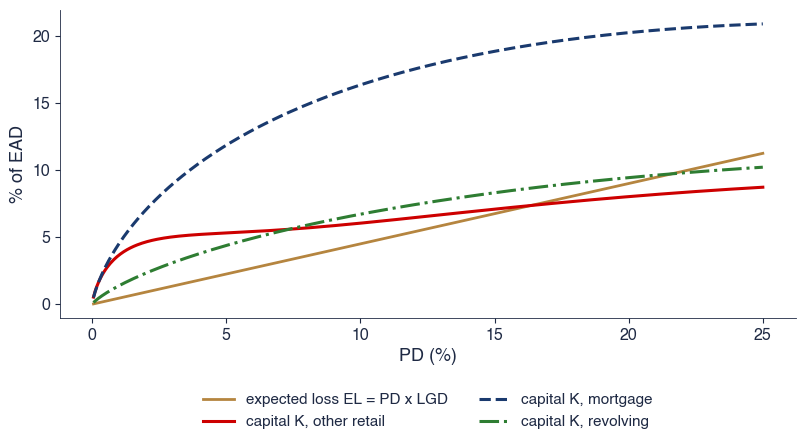

In [29]:
fig_irb(save=False)
pd.DataFrame({k: [irb_capital(p, 0.45, k)[0] for p in (0.005, 0.01, 0.02, 0.05, 0.1)] for k in ('other retail', 'mortgage', 'revolving')}, index=[0.005, 0.01, 0.02, 0.05, 0.1]).round(4)

{'0.01': {'-3': 0.13546225783467802,
  '0': 0.004648489920910667,
  '3': 2.057411875959106e-05},
 '0.02': {'-3': 0.21296920612749098,
  '0': 0.010833336300332235,
  '3': 7.347701479325741e-05},
 '0.05': {'-3': 0.36730401327271955,
  '0': 0.032957426724041484,
  '3': 0.0004203993991082089}}

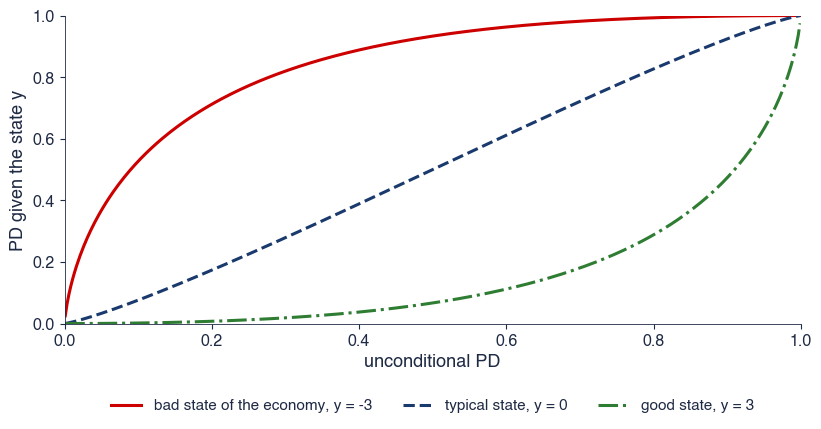

In [30]:
fig_conditional_pd(save=False)

## 9. Reject inference and fairness

- An old score accepts the best 70%; a model trained on the accepted only against one trained on all applicants.
- Approval, default and mean PD by sex and age group at a 75% approval cut-off.

In [31]:
def reject_inference_sim(T, accept=0.7):
    """The bank accepted only the 70% best applicants of an old score (late payment in the last month and the limit);
    outcomes are known only for them. A new logit trained on the accepted (inputs that never vary among them, such as
    being late last month, cannot be estimated and are dropped) is compared with one trained on all applicants
    (unknown in practice), on the test applicants: all of them (through the door) and the accepted only."""
    Z, y, tr, te = T['Z'], T['y'], T['tr'], T['te']
    OLD = ['pay0_1', 'pay0_2', 'pay0_3', 'log_limit']
    old = logit_fit(Z.iloc[tr][OLD], y[tr])
    po = logit_predict(old, Z[OLD])
    cut = np.quantile(po[tr], accept)
    acc_tr = tr[po[tr] <= cut]
    acc_te = te[po[te] <= cut]
    rej_te = np.setdiff1d(te, acc_te)
    keep = [c for c in Z.columns if Z.iloc[acc_tr][c].std() > 1e-8]
    f_acc = logit_fit(Z.iloc[acc_tr][keep], y[acc_tr])
    pa, pf = logit_predict(f_acc, Z[keep]), T['p']
    return {'cut': float(cut), 'n_acc_train': int(len(acc_tr)), 'bad_acc': float(y[acc_tr].mean()),
            'bad_rej': float(y[np.setdiff1d(tr, acc_tr)].mean()), 'bad_all': float(y[tr].mean()),
            'dropped': [c for c in Z.columns if c not in keep],
            'auc_acc_model_on_acc': auc(pa[acc_te], y[acc_te]), 'auc_acc_model_on_all': auc(pa[te], y[te]),
            'auc_all_model_on_all': auc(pf[te], y[te]), 'auc_all_model_on_acc': auc(pf[acc_te], y[acc_te]),
            'auc_old_on_all': auc(po[te], y[te]), 'mean_pd_rej_acc_model': float(pa[rej_te].mean()),
            'mean_pd_rej_all_model': float(pf[rej_te].mean()), 'rate_rejected': float(y[rej_te].mean()),
            'rate_accepted_test': float(y[acc_te].mean())}


def fairness_table(T, approve=0.75):
    """Approve the 75% of test clients with the lowest PD; by sex (1 male, 2 female) and age group: default rate,
    mean PD, approval rate, and the share of non-defaulters approved (equal opportunity)."""
    df, y, p, te = T['df'], T['y'], T['p'], T['te']
    cut = np.quantile(p[te], approve)
    d = pd.DataFrame({'y': y[te], 'p': p[te], 'ok': p[te] <= cut, 'sex': df['SEX'].values[te],
                      'age': pd.cut(df['AGE'].values[te], [0, 25, 35, 50, 100], labels=['<= 25', '26-35', '36-50', '> 50'])})
    rows = {}
    for col, lab in [('sex', {1: 'men', 2: 'women'}), ('age', None)]:
        for g, s in d.groupby(col, observed=True):
            rows[lab[g] if lab else f'age {g}'] = {'n': int(len(s)), 'rate': float(s['y'].mean()), 'pd': float(s['p'].mean()),
                                                   'approve': float(s['ok'].mean()),
                                                   'tpr_good': float(s.loc[s['y'] == 0, 'ok'].mean())}
    return {'cut': float(cut), 'groups': rows}


def fig_fairness(F, save=True):
    """Observed default rate, mean PD and approval rate by sex and age group (Taiwan test sample)."""
    g = F['groups']
    labs = list(g)
    x = np.arange(len(labs))
    fig, ax = plt.subplots(figsize=(10, 4.0))
    w = 0.26
    ax.bar(x - w, [100 * g[k]['rate'] for k in labs], w, color=st.IDAred, label='observed default rate')
    ax.bar(x, [100 * g[k]['pd'] for k in labs], w, color=st.Amber, label='mean predicted PD')
    ax.bar(x + w, [100 * g[k]['approve'] for k in labs], w, color=st.MainBlue, label='approved (cut-off: best 75%)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{k}\n(n = {g[k]["n"]})' for k in labs])
    ax.set_ylabel('%')
    ax.set_ylim(0, 100)
    st.legend_outside_bottom(ax, ncol=3, y=-0.24)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_fairness')

In [32]:
reject_inference_sim(T)

{'cut': 0.19290971292763623,
 'n_acc_train': 15085,
 'bad_acc': 0.13205170699370236,
 'bad_rej': 0.4485207100591716,
 'bad_all': 0.2211904761904762,
 'dropped': ['pay0_1', 'pay0_2', 'pay0_3'],
 'auc_acc_model_on_acc': 0.6634272658067137,
 'auc_acc_model_on_all': 0.7359157369526831,
 'auc_all_model_on_all': 0.7771611214654847,
 'auc_all_model_on_acc': 0.6590401065934687,
 'auc_old_on_all': 0.742935698874354,
 'mean_pd_rej_acc_model': 0.2964128409742613,
 'mean_pd_rej_all_model': 0.44057045592662414,
 'rate_rejected': 0.4612,
 'rate_accepted_test': 0.12892307692307692}

,n,rate,pd,approve,tpr_good
men,3574.0,0.247,0.232,0.725,0.832
women,5426.0,0.205,0.211,0.766,0.851
age <= 25,1153.0,0.258,0.260,0.683,0.800
age 26-35,3836.0,0.200,0.200,0.778,0.861
age 36-50,3291.0,0.225,0.219,0.755,0.851
age > 50,720.0,0.254,0.258,0.681,0.786


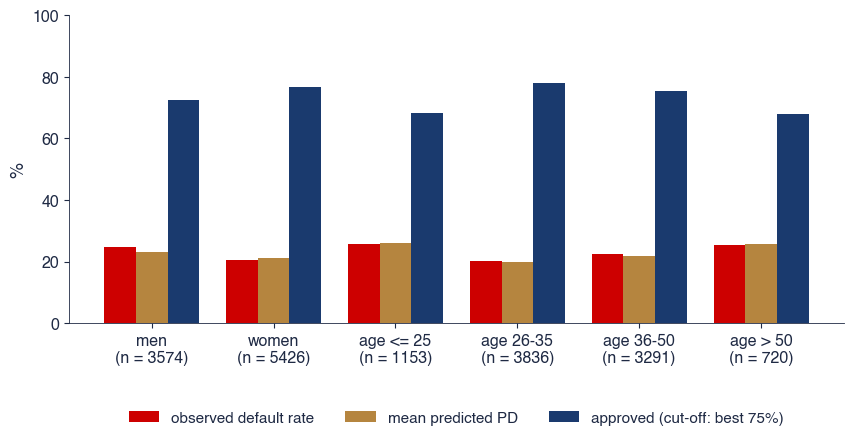

In [33]:
F = fairness_table(T)
fig_fairness(F, save=False)
pd.DataFrame(F['groups']).T.round(3)

## 10. Altman Z-score and Merton distance to default

In [34]:
def altman_z(x1, x2, x3, x4, x5):
    """Altman (1968) Z = 1.2 X1 + 1.4 X2 + 3.3 X3 + 0.6 X4 + 1.0 X5 (ratios as decimals): X1 working capital /
    total assets, X2 retained earnings / TA, X3 EBIT / TA, X4 market value of equity / book value of total debt,
    X5 sales / TA. Zones: Z < 1.81 distress, 1.81-2.99 grey, Z > 2.99 safe."""
    z = 1.2 * x1 + 1.4 * x2 + 3.3 * x3 + 0.6 * x4 + 1.0 * x5
    return {'z': float(z), 'zone': 'distress' if z < 1.81 else 'grey' if z <= 2.99 else 'safe'}


def merton_dd(V, D, sigma, mu=0.05, T=1.0):
    """Merton (1974): assets follow a GBM (Chapter 4); default if V_T < D. DD = [ln(V/D) + (mu - sigma^2/2) T] /
    (sigma sqrt(T)), PD = N(-DD)."""
    dd = (np.log(V / D) + (mu - 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return {'dd': float(dd), 'pd': float(stats.norm.cdf(-dd))}


def merton_from_equity(E, sigma_E, D, r=0.03, T=1.0):
    """Solve E = V N(d1) - D e^{-rT} N(d2) and sigma_E E = N(d1) sigma_V V for (V, sigma_V); risk-neutral DD."""
    def eqs(z):
        V, s = np.exp(z[0]), np.exp(z[1])
        d1 = (np.log(V / D) + (r + 0.5 * s ** 2) * T) / (s * np.sqrt(T))
        d2 = d1 - s * np.sqrt(T)
        return [V * stats.norm.cdf(d1) - D * np.exp(-r * T) * stats.norm.cdf(d2) - E,
                stats.norm.cdf(d1) * s * V - sigma_E * E]
    z = optimize.fsolve(eqs, [np.log(E + D), np.log(sigma_E * E / (E + D))])
    V, s = float(np.exp(z[0])), float(np.exp(z[1]))
    dd = (np.log(V / D) + (r - 0.5 * s ** 2) * T) / (s * np.sqrt(T))
    return {'V': V, 'sigma_V': s, 'dd': float(dd), 'pd': float(stats.norm.cdf(-dd))}


def fig_merton(save=True):
    """Left: asset paths of a GBM and the default barrier D. Right: PD = N(-DD) against leverage D/V."""
    rng = np.random.default_rng(SEED)
    V0, D, mu, s, T, n = 100.0, 70.0, 0.05, 0.25, 1.0, 252
    dt = T / n
    Z = rng.standard_normal((40, n))
    paths = V0 * np.exp(np.cumsum((mu - 0.5 * s ** 2) * dt + s * np.sqrt(dt) * Z, axis=1))
    paths = np.column_stack([np.full(40, V0), paths])
    tgrid = np.linspace(0, T, n + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    ax = axes[0]
    for i, pth in enumerate(paths):
        d = pth[-1] < D
        ax.plot(tgrid, pth, color=st.IDAred if d else st.MainBlue, lw=1.0 if d else 0.6, alpha=0.9 if d else 0.5,
                label=('default at T: V_T < D' if d else 'no default at T') if i in (int(np.argmax(paths[:, -1] < D)),
                                                                                  int(np.argmax(paths[:, -1] >= D))) else None)
    ax.axhline(D, color=st.Amber, lw=2, ls='--', label='debt D = 70')
    ax.set_xlabel('time (years)')
    ax.set_ylabel('asset value V')
    ax = axes[1]
    lev = np.linspace(0.3, 0.95, 200)
    for sig, c, ls in [(0.15, st.Forest, '-'), (0.25, st.MainBlue, '--'), (0.40, st.IDAred, '-.')]:
        ax.plot(100 * lev, [100 * merton_dd(1.0, L, sig, mu, T)['pd'] for L in lev], color=c, lw=2.2, ls=ls,
                label=f'asset volatility {int(100 * sig)}%')
    ax.set_xlabel('leverage D / V (%)')
    ax.set_ylabel('one-year PD (%)')
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.fig_legend_bottom(fig, ncol=3, y=0.08)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch12_merton')
    return {'share_default': float(np.mean(paths[:, -1] < D))}

{'z': 2.364, 'zone': 'grey'}
{'dd': 1.5016997757549295, 'pd': 0.06658733092267571}
{'V': 107.89769326297198, 'sigma_V': 0.18628947463242973, 'dd': 2.390561078205986, 'pd': 0.008411325375875026}


{'share_default': 0.075}

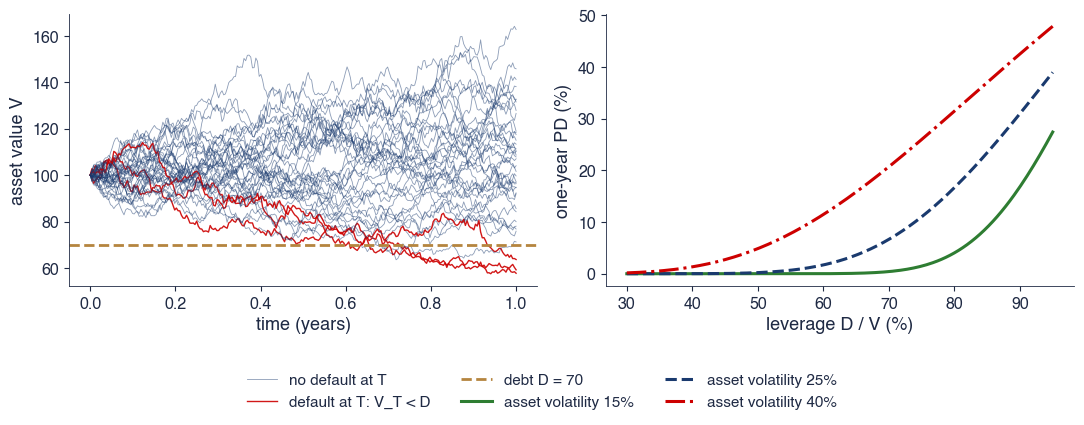

In [35]:
print(altman_z(0.15, 0.20, 0.08, 0.90, 1.10))
print(merton_dd(100, 70, 0.25, 0.05, 1.0))
print(merton_from_equity(40, 0.5, 70, 0.03, 1.0))
fig_merton(save=False)

## 11. AI for scientific discovery: is the gain of flexible models worth their cost?

- Open question: do flexible machine-learning scores improve default prediction enough to justify the loss of transparency, and are the gains equal across groups?
- Starter result: how well does the Taiwan logit rank and calibrate within each group?
- Check before trusting any answer, yours or an AI's: the coding of default, the WoE sign convention, no leakage of the test sample into the bins, AUC is not accuracy, Gini = 2 AUC − 1, prior correction before EL or capital.

In [36]:
te = T['te']
sex = T['df']['SEX'].values[te]
age = T['df']['AGE'].values[te]
y, p = T['y'][te], T['p'][te]
groups = {'men': sex == 1, 'women': sex == 2, 'age <= 25': age <= 25, 'age 26-50': (age > 25) & (age <= 50), 'age > 50': age > 50}
pd.DataFrame({g_: {'n': int(m.sum()), 'AUC': auc(p[m], y[m]), 'mean PD': p[m].mean(), 'default rate': y[m].mean(), 'Brier': brier(p[m], y[m])} for g_, m in groups.items()}).T.round(3)

,n,AUC,mean PD,default rate,Brier
men,3574.0,0.781,0.232,0.247,0.147
women,5426.0,0.773,0.211,0.205,0.129
age <= 25,1153.0,0.772,0.260,0.258,0.149
age 26-50,7127.0,0.778,0.209,0.212,0.132
age > 50,720.0,0.761,0.258,0.254,0.157
